In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
from torch import nn
import numpy as np

In [2]:
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"Number of directories: {len(dirnames)}, Number of images: {len(filenames)} in '{dirpath}'.")

In [3]:
from pathlib import Path
data_path = Path("../data/")
image_path = data_path / "desert101"

In [4]:
check_data(image_path)

Number of directories: 2, Number of images: 1 in '..\data\desert101'.
Number of directories: 4, Number of images: 1 in '..\data\desert101\test'.
Number of directories: 0, Number of images: 20 in '..\data\desert101\test\baklava'.
Number of directories: 0, Number of images: 20 in '..\data\desert101\test\cannoli'.
Number of directories: 0, Number of images: 20 in '..\data\desert101\test\cup_cakes'.
Number of directories: 0, Number of images: 20 in '..\data\desert101\test\donuts'.
Number of directories: 4, Number of images: 1 in '..\data\desert101\train'.
Number of directories: 0, Number of images: 80 in '..\data\desert101\train\baklava'.
Number of directories: 0, Number of images: 80 in '..\data\desert101\train\cannoli'.
Number of directories: 0, Number of images: 80 in '..\data\desert101\train\cup_cakes'.
Number of directories: 0, Number of images: 80 in '..\data\desert101\train\donuts'.


In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [6]:
from PIL import Image
import random

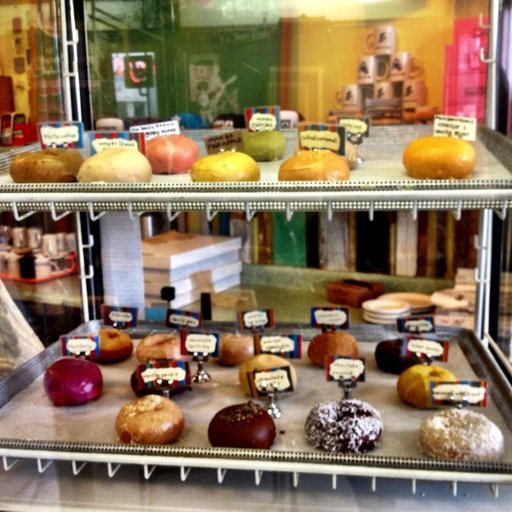

In [7]:
random.seed(42)
img = random.choice(list(image_path.glob("*/*/*.jpg")))
Image.open(img)

In [8]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [9]:
image_size_tuple = (64, 64)

data_transform = transforms.Compose([
    transforms.Resize(image_size_tuple),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()
])

In [10]:
trainData = datasets.ImageFolder(train_dir, transform=data_transform, target_transform=None)
testData = datasets.ImageFolder(test_dir, transform=data_transform, target_transform=None)

In [11]:
trainData

Dataset ImageFolder
    Number of datapoints: 316
    Root location: ..\data\desert101\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [12]:
testData

Dataset ImageFolder
    Number of datapoints: 77
    Root location: ..\data\desert101\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [13]:
classNames = testData.classes
classNames

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [14]:
print(f"Number of training samples: {len(trainData)}")
print(f"Number of test samples: {len(testData)}")

Number of training samples: 316
Number of test samples: 77


In [15]:
BATCH_SIZE = 32
number_of_workers = os.cpu_count()

In [16]:
number_of_workers

16

In [17]:
train_dataloader = DataLoader(trainData, batch_size=32, shuffle=True, num_workers=number_of_workers)
test_dataloader = DataLoader(testData, batch_size=32, shuffle=False, num_workers=number_of_workers)


In [18]:
train_dataloader.dataset[0][0]

tensor([[[0.6000, 0.5922, 0.5333,  ..., 0.4784, 0.4510, 0.4588],
         [0.5529, 0.5098, 0.5569,  ..., 0.4471, 0.4706, 0.0000],
         [0.5608, 0.6314, 0.6824,  ..., 0.5490, 0.0000, 0.0000],
         ...,
         [0.8353, 0.8235, 0.8000,  ..., 0.0000, 0.0000, 0.0000],
         [0.8039, 0.8196, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.8157, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.4824, 0.4784, 0.4196,  ..., 0.3490, 0.3137, 0.3216],
         [0.4431, 0.4000, 0.4353,  ..., 0.3333, 0.3569, 0.0000],
         [0.4392, 0.4902, 0.5373,  ..., 0.4078, 0.0000, 0.0000],
         ...,
         [0.5961, 0.5725, 0.5412,  ..., 0.0000, 0.0000, 0.0000],
         [0.5686, 0.5765, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.6000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.2118, 0.2157, 0.1686,  ..., 0.0980, 0.0863, 0.0902],
         [0.1804, 0.1490, 0.1608,  ..., 0.1020, 0.1137, 0.0000],
         [0.1529, 0.1686, 0.2118,  ..., 0.1059, 0.0000, 0.

In [19]:
class DesertClassifier(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) ->None:
        super().__init__()

        self.firstConvBlock = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.secondConvBlock = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units * 16 * 16, out_features=output_shape)
        )

    def forward(self, x):
        return self.classifier(self.secondConvBlock(self.firstConvBlock(x)))


In [20]:
classCount = len(classNames)
model = DesertClassifier(input_shape= 3, hidden_units= 32, output_shape=classCount)

In [21]:
!pip install torchinfo

Defaulting to user installation because normal site-packages is not writeable


In [22]:
from torchinfo import summary
summary(model, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [23]:
def trainStep(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer):

    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X, y) in enumerate(dataloader):

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predictedClass = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (predictedClass == y).sum().item() / len(y_pred)

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc

In [24]:
def testStep(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module,):

    model.eval()
    test_loss = 0
    test_acc = 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            test_loss += loss.item()

            testPredictedLabels = y_pred.argmax(dim=1)
            test_acc += (testPredictedLabels == y).sum().item() / len(y_pred)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc


In [25]:
def train(model: torch.nn.Module, train_dataloader: torch.utils.data.DataLoader, test_dataloader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer, loss_fn: torch.nn.Module = nn.CrossEntropyLoss(), epochs: int = 10):

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = trainStep(model= model, dataloader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer)
        test_loss, test_acc = trainStep(model= model, dataloader=test_dataloader, loss_fn=loss_fn, optimizer=optimizer)

        print(f"Epoch: {epoch + 1}, Train loss: {train_loss}, Test loss: {test_loss}, Train acc: {train_acc}, Test acc: {test_acc}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results


In [26]:
torch.compile(model, backend="cudagraphs")
EPOCHS = 20
modelResults = train(model=model, train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizer=torch.optim.Adam(params = model.parameters(), lr=0.001), loss_fn = nn.CrossEntropyLoss(), epochs=EPOCHS)

Epoch: 1, Train loss: 1.3957998156547546, Test loss: 1.39509113629659, Train acc: 0.22723214285714283, Test acc: 0.03125
Epoch: 2, Train loss: 1.386916983127594, Test loss: 1.3854848941167195, Train acc: 0.24375, Test acc: 0.3701923076923077
Epoch: 3, Train loss: 1.3859840631484985, Test loss: 1.381823182106018, Train acc: 0.25044642857142857, Test acc: 0.3958333333333333
Epoch: 4, Train loss: 1.3851608157157898, Test loss: 1.3760757446289062, Train acc: 0.25089285714285714, Test acc: 0.3958333333333333
Epoch: 5, Train loss: 1.380189883708954, Test loss: 1.3726615111033122, Train acc: 0.25669642857142855, Test acc: 0.2371794871794872
Epoch: 6, Train loss: 1.356656539440155, Test loss: 1.4175992012023926, Train acc: 0.28035714285714286, Test acc: 0.2756410256410256
Epoch: 7, Train loss: 1.327301847934723, Test loss: 1.3304171164830525, Train acc: 0.34955357142857146, Test acc: 0.375
Epoch: 8, Train loss: 1.3029939889907838, Test loss: 1.3387988408406575, Train acc: 0.3607142857142857, T

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_loss_curver(results):
    loss = results["train_loss"]
    test_loss = results["test_loss"]
    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_acc")
    plt.plot(epochs, test_accuracy, label="test_acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

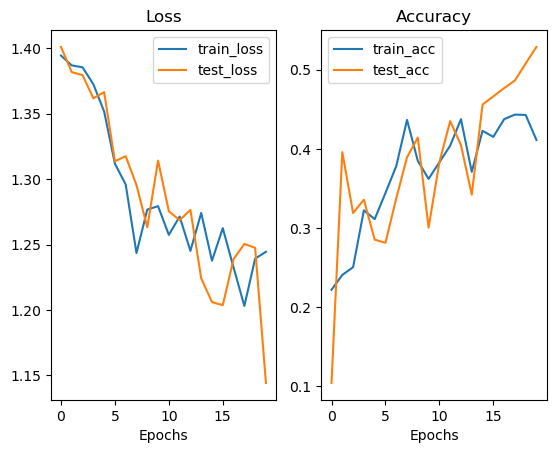

In [ ]:
plot_loss_curver(modelResults)

In [ ]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # choose n random indices from the dataset
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # prepare the image for the model
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # permute for visualization
            img_show = img.permute(1, 2, 0)

            # true or false?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

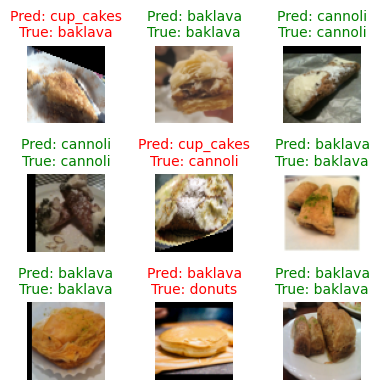

In [ ]:
show_random_predictions(model, testData, class_names=classNames)

In [ ]:
online_image_path = data_path / "baklava.jpg"

In [ ]:
import torchvision

In [ ]:
single_img = torchvision.io.read_image(str(online_image_path)).type(torch.float32)

In [ ]:
single_img

tensor([[[230., 230., 230.,  ..., 230., 230., 230.],
         [231., 231., 231.,  ..., 230., 230., 230.],
         [231., 231., 231.,  ..., 230., 230., 230.],
         ...,
         [218., 218., 218.,  ..., 219., 219., 220.],
         [217., 217., 217.,  ..., 219., 219., 220.],
         [216., 216., 216.,  ..., 218., 219., 220.]],

        [[232., 232., 232.,  ..., 237., 237., 237.],
         [233., 233., 233.,  ..., 237., 237., 237.],
         [233., 233., 233.,  ..., 237., 237., 237.],
         ...,
         [225., 225., 225.,  ..., 226., 226., 227.],
         [224., 224., 224.,  ..., 226., 226., 227.],
         [223., 223., 223.,  ..., 225., 226., 227.]],

        [[245., 245., 245.,  ..., 243., 243., 243.],
         [246., 246., 246.,  ..., 243., 243., 243.],
         [245., 245., 245.,  ..., 243., 243., 243.],
         ...,
         [235., 235., 235.,  ..., 236., 236., 237.],
         [234., 234., 234.,  ..., 236., 236., 237.],
         [233., 233., 233.,  ..., 235., 236., 237.]]]

In [ ]:
single_img = single_img.divide(255)

Text(0.5, 1.0, 'torch.Size([3, 751, 1000])')

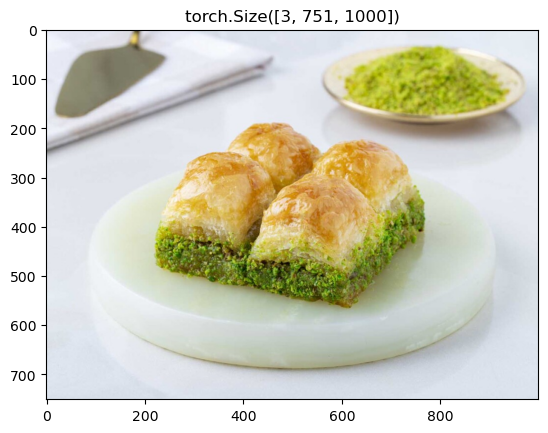

In [ ]:
plt.imshow(single_img.permute(1, 2, 0))
plt.title(single_img.shape)

In [ ]:
single_image_transform = transforms.Compose([
    transforms.Resize(size=(64, 64))
])
single_img = single_image_transform(single_img).unsqueeze(dim=0)
single_img.shape

torch.Size([1, 3, 64, 64])

In [ ]:
model.eval()
with torch.inference_mode():
    logits = model(single_img)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()

print("Predicted class: " + classNames[pred_idx])

Predicted class: baklava
